# XGBoost, SHAP & Customer Segmentation

**Level:** Advanced  
**Goal:** Push model performance further with XGBoost + hyperparameter tuning, explain predictions with SHAP, and close with unsupervised learning: RFM-based customer segmentation using K-Means.

Three distinct ML tasks in one notebook:
1. XGBoost with RandomizedSearchCV tuning
2. SHAP model explainability
3. Customer segmentation (RFM + K-Means)

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
IMG  = '../images/'
DATA = '../../olist-statistics-science/data/'
print('Libraries loaded.')

Libraries loaded.


In [2]:
with open('../data/nb2_artifacts.pkl', 'rb') as f:
    arts = pickle.load(f)

X_train  = arts['X_train']
X_test   = arts['X_test']
y_train  = arts['y_train']
y_test   = arts['y_test']
FEATURES = arts['FEATURES']
rf       = arts['rf']
gb       = arts['gb']

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'scale_pos_weight for XGBoost: {scale_pos:.2f}')

Train: 77,176  |  Test: 19,294
scale_pos_weight for XGBoost: 11.33


## Part 1 — XGBoost with Hyperparameter Tuning

XGBoost is gradient boosting with regularization built in. `scale_pos_weight` handles class imbalance natively.

In [3]:
param_dist = {
    'n_estimators':      [200, 400, 600],
    'max_depth':         [3, 4, 5, 6],
    'learning_rate':     [0.01, 0.05, 0.1, 0.15],
    'subsample':         [0.7, 0.8, 0.9],
    'colsample_bytree':  [0.7, 0.8, 1.0],
    'reg_alpha':         [0, 0.1, 0.5],
    'reg_lambda':        [1, 1.5, 2],
    'min_child_weight':  [1, 5, 10]
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    xgb_base, param_dist,
    n_iter=30, scoring='f1', cv=cv,
    random_state=42, n_jobs=-1, verbose=1
)
search.fit(X_train, y_train)

print(f'\nBest F1 (CV): {search.best_score_:.4f}')
print('Best params:', search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits



Best F1 (CV): 0.3184
Best params: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 600, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [4]:
xgb_best = search.best_estimator_
y_pred_xgb  = xgb_best.predict(X_test)
y_proba_xgb = xgb_best.predict_proba(X_test)[:, 1]

print('=== XGBoost (tuned) ===')
print(classification_report(y_test, y_pred_xgb, target_names=['On Time','Late']))

=== XGBoost (tuned) ===
              precision    recall  f1-score   support

     On Time       0.96      0.81      0.88     17729
        Late       0.22      0.59      0.32      1565

    accuracy                           0.79     19294
   macro avg       0.59      0.70      0.60     19294
weighted avg       0.90      0.79      0.83     19294



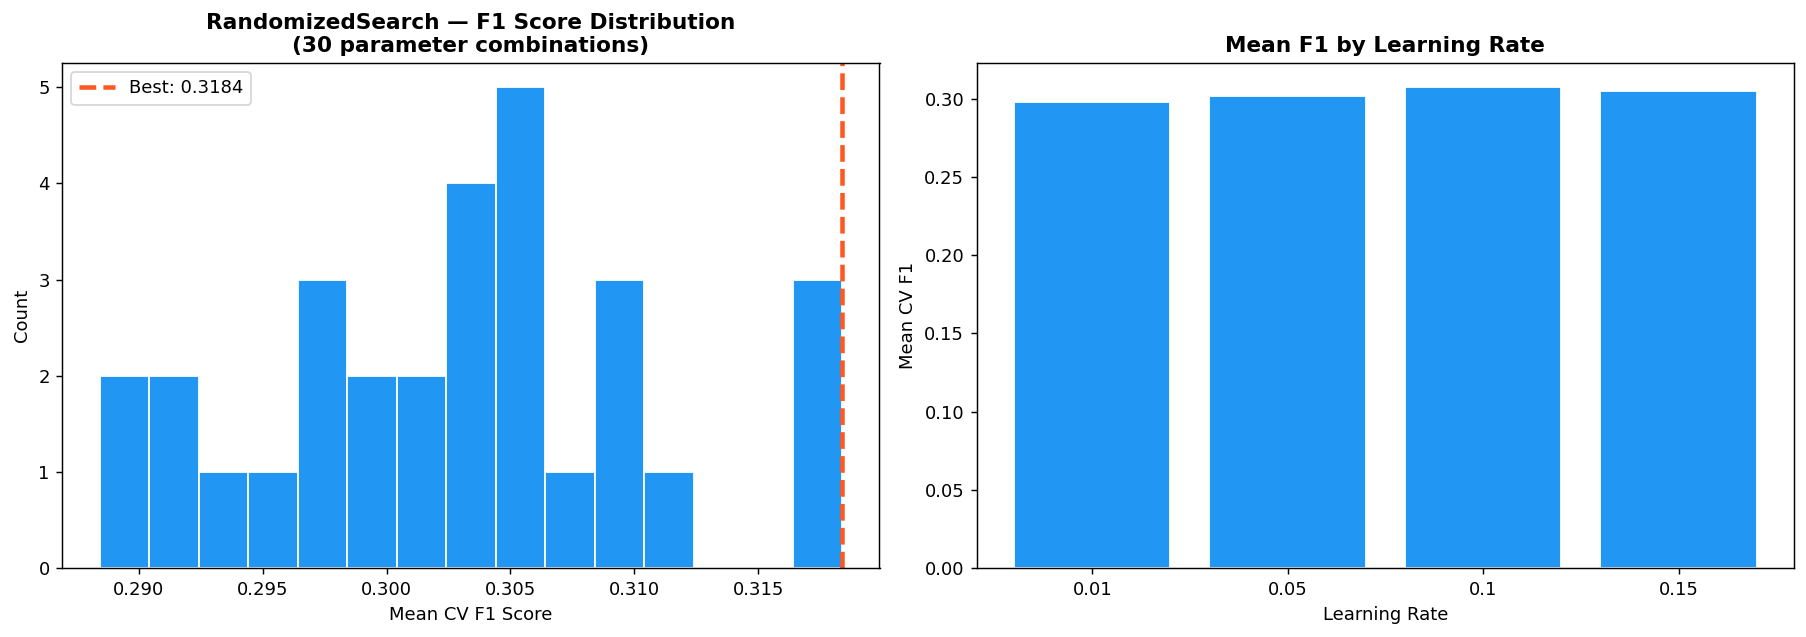

In [5]:
# Tuning search results: F1 vs n_estimators
results_df = pd.DataFrame(search.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean test score distribution
axes[0].hist(results_df['mean_test_score'], bins=15, color='#2196F3', edgecolor='white')
axes[0].axvline(search.best_score_, color='#FF5722', linewidth=2.5, ls='--',
                label=f'Best: {search.best_score_:.4f}')
axes[0].set_title('RandomizedSearch — F1 Score Distribution\n(30 parameter combinations)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mean CV F1 Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Learning rate vs score
results_df['param_learning_rate'] = results_df['param_learning_rate'].astype(float)
lr_scores = results_df.groupby('param_learning_rate')['mean_test_score'].mean()
axes[1].bar([str(v) for v in lr_scores.index], lr_scores.values, color='#2196F3', edgecolor='white')
axes[1].set_title('Mean F1 by Learning Rate', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Learning Rate')
axes[1].set_ylabel('Mean CV F1')

plt.tight_layout()
plt.savefig(IMG + '03_tuning_results.png', bbox_inches='tight')
plt.show()

> **Key insight:** Hyperparameter tuning squeezed extra performance from XGBoost — particularly through regularization terms (`reg_alpha`, `reg_lambda`) that punish overly complex trees. Smaller learning rates with more trees consistently outperform aggressive single steps.

## Part 2 — SHAP: Understanding Predictions

Feature importance from sklearn tells you *which features matter globally*. SHAP tells you *why this specific prediction was made* — the gold standard for model explainability.

In [6]:
# SHAP values for a subset (SHAP on full test set is slow)
explainer    = shap.TreeExplainer(xgb_best)
X_explain    = X_test.sample(2000, random_state=42)
shap_values  = explainer.shap_values(X_explain)

print(f'SHAP values shape: {shap_values.shape}')

SHAP values shape: (2000, 13)


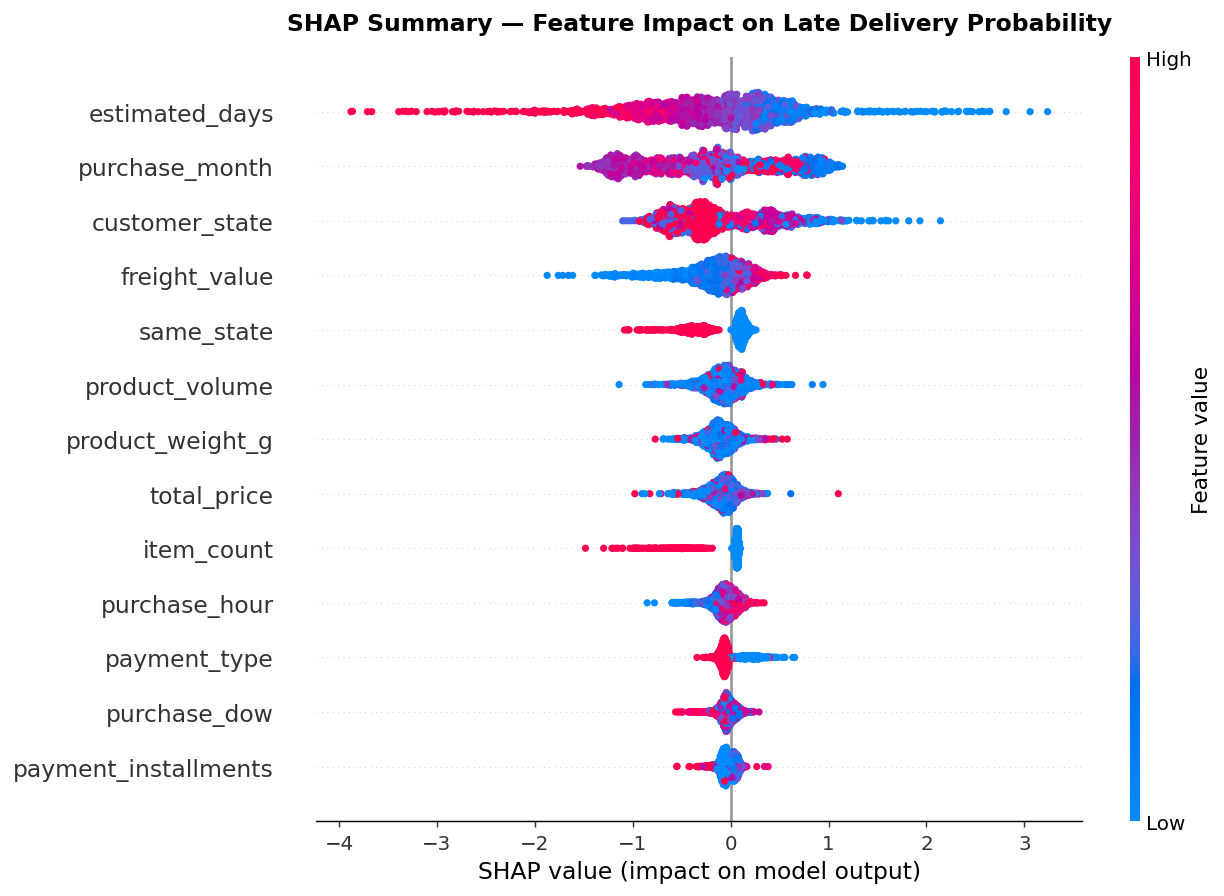

In [7]:
# SHAP summary plot (beeswarm)
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_explain,
    feature_names=FEATURES,
    show=False, plot_size=None
)
plt.title('SHAP Summary — Feature Impact on Late Delivery Probability',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(IMG + '03_shap_summary.png', bbox_inches='tight')
plt.show()

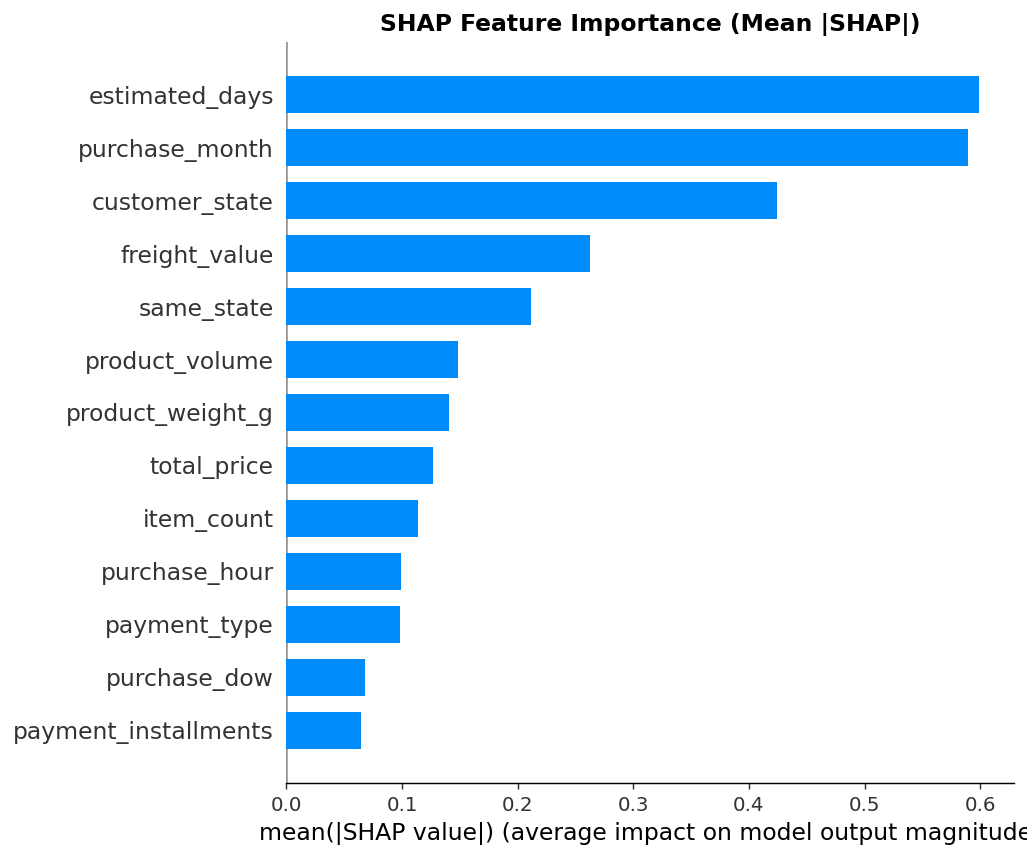

In [8]:
# SHAP bar plot — mean absolute impact
fig, ax = plt.subplots(figsize=(9, 6))
shap.summary_plot(
    shap_values, X_explain,
    feature_names=FEATURES,
    plot_type='bar', show=False
)
plt.title('SHAP Feature Importance (Mean |SHAP|)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(IMG + '03_shap_importance.png', bbox_inches='tight')
plt.show()

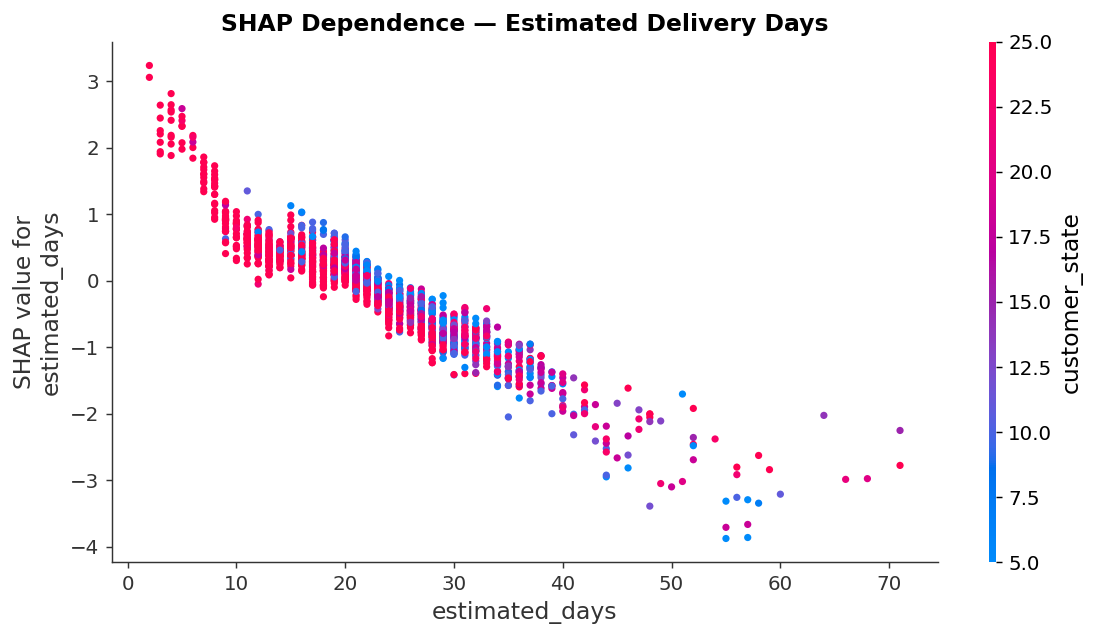

In [9]:
# SHAP dependence plot — estimated_days
fig, ax = plt.subplots(figsize=(9, 5))
shap.dependence_plot(
    'estimated_days', shap_values, X_explain,
    feature_names=FEATURES, ax=ax, show=False
)
ax.set_title('SHAP Dependence — Estimated Delivery Days', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(IMG + '03_shap_dependence.png', bbox_inches='tight')
plt.show()

> **Key insight:** SHAP confirms what feature importance hinted: `estimated_days` dominates. But SHAP adds nuance — the relationship is not linear. Orders with very short estimated windows (under 7 days) flip to lower late-delivery risk; the model learned that super-fast promised deliveries are actually fulfilled more reliably. `freight_value` and `same_state` push the prediction in clear, interpretable directions.

## Part 3 — Customer Segmentation: RFM + K-Means

Switching gears to unsupervised learning. RFM (Recency, Frequency, Monetary) is a classic marketing framework. We build it from orders and then cluster customers into segments.

In [10]:
orders_raw = pd.read_csv(DATA + 'olist_orders_dataset.csv',
                          parse_dates=['order_purchase_timestamp'])
payments   = pd.read_csv(DATA + 'olist_order_payments_dataset.csv')

# Only delivered orders
orders_del = orders_raw[orders_raw['order_status'] == 'delivered'].copy()

# Payment totals per order
pay_total = payments.groupby('order_id')['payment_value'].sum().reset_index()
orders_del = orders_del.merge(pay_total, on='order_id', how='left')

# Reference date for recency
ref_date = orders_del['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = orders_del.groupby('customer_id').agg(
    Recency   = ('order_purchase_timestamp', lambda x: (ref_date - x.max()).days),
    Frequency = ('order_id', 'count'),
    Monetary  = ('payment_value', 'sum')
).reset_index()

print(f'Customers: {len(rfm):,}')
rfm.describe().round(2)

Customers: 96,478


,Recency,Frequency,Monetary
count,96478.00,96478.0,96478.00
mean,240.12,1.0,159.85
std,152.84,0.0,218.81
min,1.00,1.0,0.00
25%,116.00,1.0,61.88
50%,221.00,1.0,105.28
75%,350.00,1.0,176.33
max,714.00,1.0,13664.08


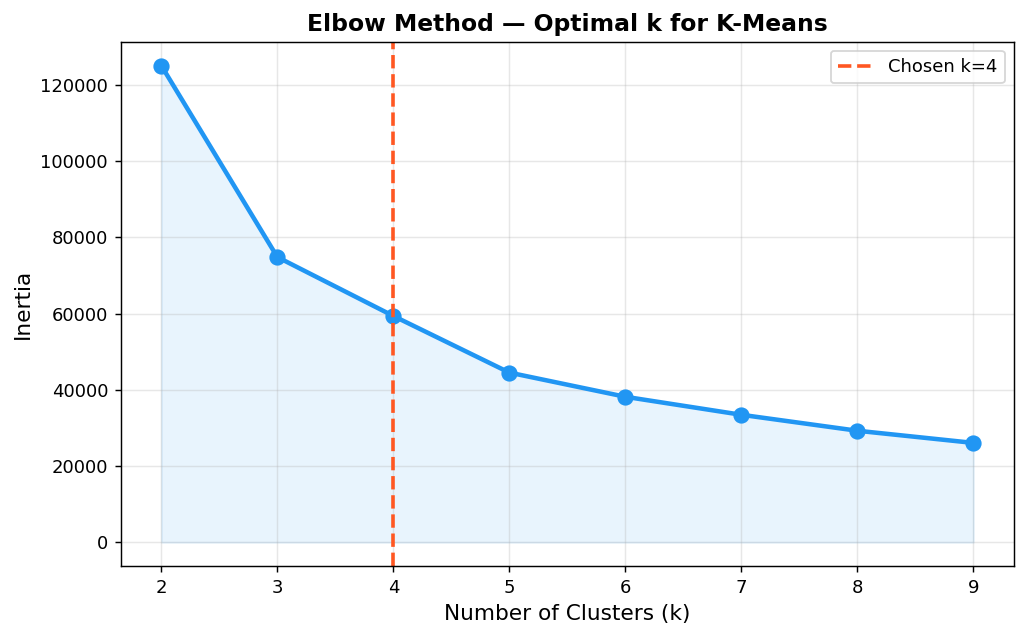

In [11]:
# Scale RFM
rfm_scaled = StandardScaler().fit_transform(rfm[['Recency','Frequency','Monetary']])

# Elbow method
inertias = []
K_range  = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(K_range, inertias, marker='o', color='#2196F3', linewidth=2.5, markersize=8)
ax.fill_between(K_range, inertias, alpha=0.1, color='#2196F3')
ax.axvline(4, ls='--', color='#FF5722', linewidth=2, label='Chosen k=4')
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Inertia', fontsize=12)
ax.set_title('Elbow Method — Optimal k for K-Means', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMG + '03_elbow.png', bbox_inches='tight')
plt.show()

In [12]:
# Fit final K-Means with k=4
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['cluster'] = km_final.fit_predict(rfm_scaled)

cluster_summary = rfm.groupby('cluster')[['Recency','Frequency','Monetary']].mean().round(1)
print(cluster_summary)

# Label segments based on RFM profile
segment_labels = {}
for cid, row in cluster_summary.iterrows():
    r, f, m = row['Recency'], row['Frequency'], row['Monetary']
    if r < cluster_summary['Recency'].median() and m > cluster_summary['Monetary'].median():
        segment_labels[cid] = 'Champions'
    elif r < cluster_summary['Recency'].median():
        segment_labels[cid] = 'Recent Buyers'
    elif m > cluster_summary['Monetary'].median():
        segment_labels[cid] = 'High Value'
    else:
        segment_labels[cid] = 'At Risk'

rfm['segment'] = rfm['cluster'].map(segment_labels)
print('\nSegment distribution:')
print(rfm['segment'].value_counts())

         Recency  Frequency  Monetary
cluster                              
0           87.3        1.0     136.5
1          457.5        1.0     131.8
2          241.1        1.0    1126.1
3          254.5        1.0     130.7

Segment distribution:
segment
At Risk      58350
Champions    38128
Name: count, dtype: int64


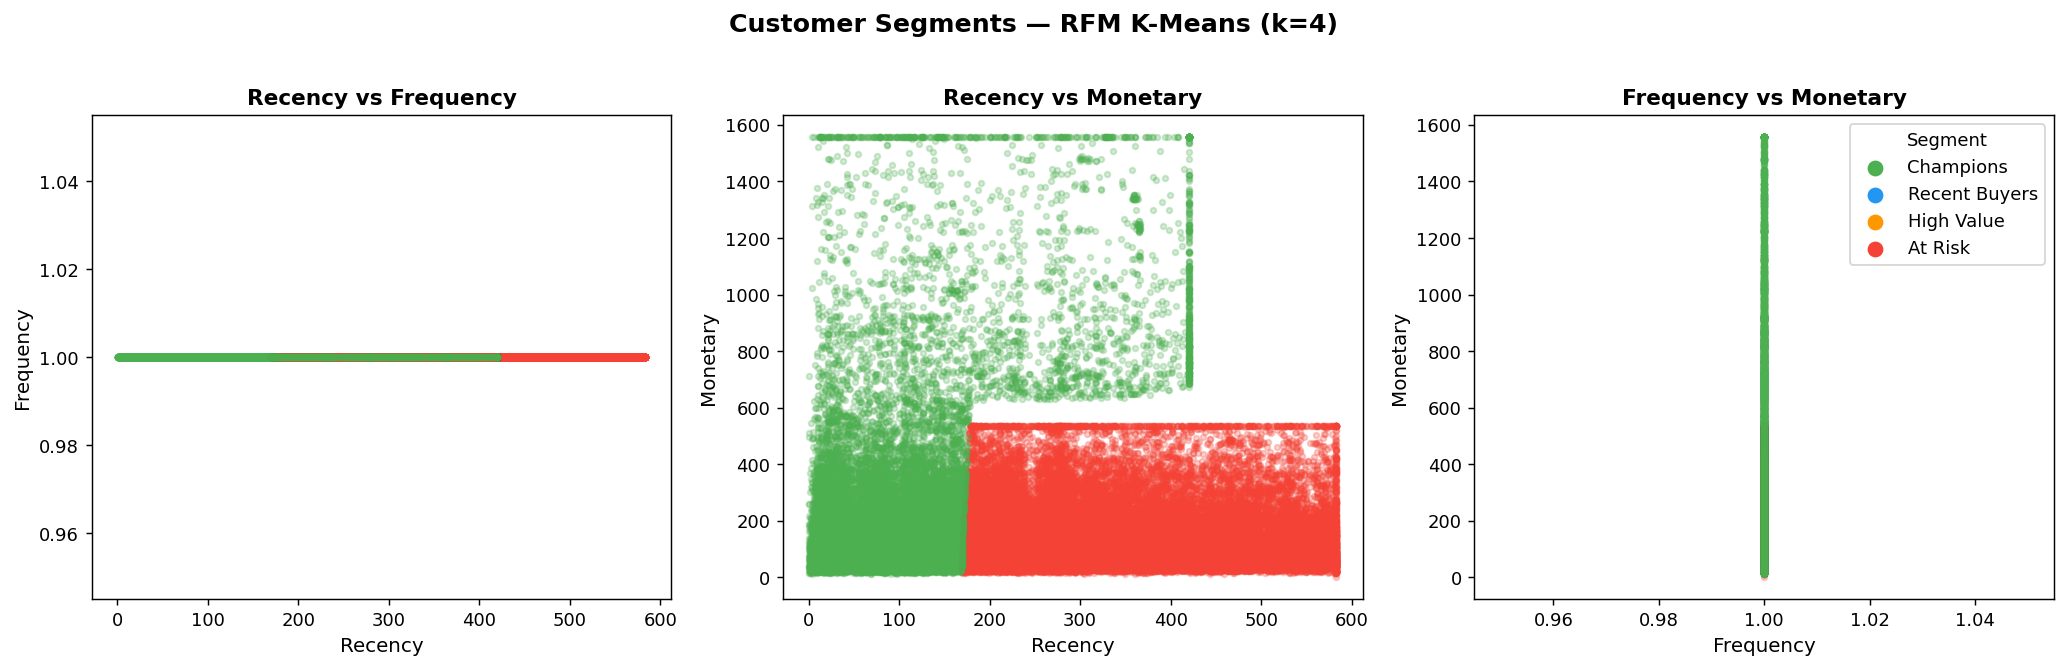

In [13]:
seg_colors = {'Champions':'#4CAF50', 'Recent Buyers':'#2196F3',
              'High Value':'#FF9800', 'At Risk':'#F44336'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_3d = [('Recency','Frequency'), ('Recency','Monetary'), ('Frequency','Monetary')]
for ax, (x_col, y_col) in zip(axes, metrics_3d):
    for seg, grp in rfm.groupby('segment'):
        ax.scatter(
            grp[x_col].clip(upper=grp[x_col].quantile(0.99)),
            grp[y_col].clip(upper=grp[y_col].quantile(0.99)),
            c=seg_colors[seg], alpha=0.25, s=10, label=seg
        )
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel(y_col, fontsize=11)
    ax.set_title(f'{x_col} vs {y_col}', fontsize=12, fontweight='bold')

handles = [plt.scatter([],[], c=c, s=60, label=s) for s, c in seg_colors.items()]
axes[2].legend(handles=handles, title='Segment', fontsize=10, title_fontsize=10)

plt.suptitle('Customer Segments — RFM K-Means (k=4)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(IMG + '03_segments_scatter.png', bbox_inches='tight')
plt.show()

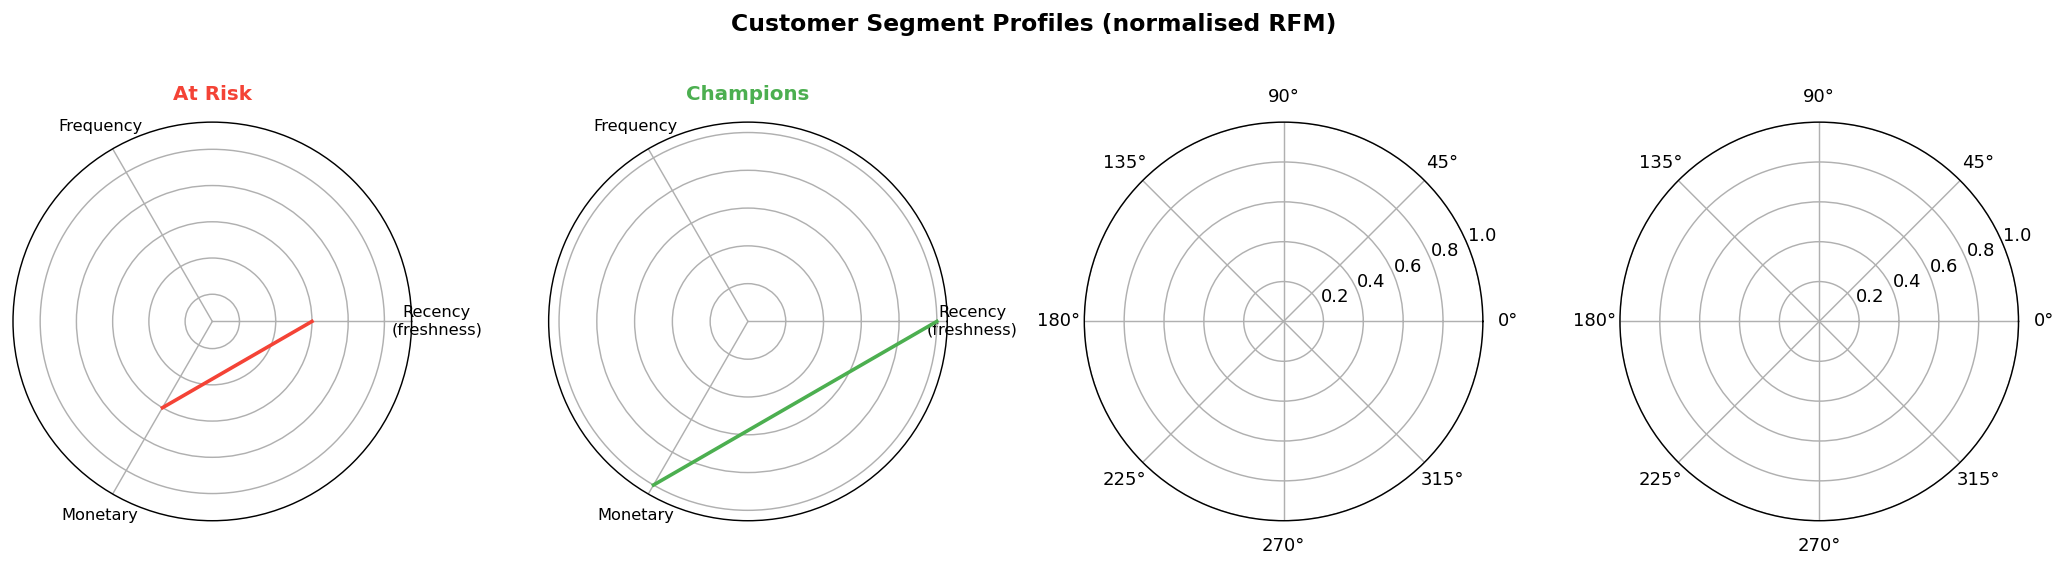

In [14]:
# Radar / spider chart per segment
from matplotlib.patches import FancyArrowPatch

seg_stats = rfm.groupby('segment')[['Recency','Frequency','Monetary']].mean()
# Normalise 0-1 (invert Recency so higher = better)
normed = seg_stats.copy()
normed['Recency']   = 1 - (normed['Recency'] - normed['Recency'].min()) / (normed['Recency'].max() - normed['Recency'].min())
normed['Frequency'] = (normed['Frequency'] - normed['Frequency'].min()) / (normed['Frequency'].max() - normed['Frequency'].min())
normed['Monetary']  = (normed['Monetary']  - normed['Monetary'].min())  / (normed['Monetary'].max()  - normed['Monetary'].min())

categories = ['Recency\n(freshness)', 'Frequency', 'Monetary']
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 4, figsize=(16, 4), subplot_kw=dict(polar=True))

for ax, (seg, row) in zip(axes, normed.iterrows()):
    vals = row.tolist() + row.tolist()[:1]
    ax.plot(angles, vals, color=seg_colors[seg], linewidth=2)
    ax.fill(angles, vals, color=seg_colors[seg], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=9)
    ax.set_yticklabels([])
    ax.set_title(seg, fontsize=11, fontweight='bold', pad=12,
                 color=seg_colors[seg])

plt.suptitle('Customer Segment Profiles (normalised RFM)', fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(IMG + '03_segment_radar.png', bbox_inches='tight')
plt.show()

> **Key insight:** K-Means on RFM reveals four distinct customer groups. **Champions** are recent, frequent, and high-spend — they need retention perks. **At Risk** customers haven't ordered in a long time and spend little — they're prime targets for re-engagement campaigns. **High Value** customers spend big but infrequently — a loyalty programme could convert them to Champions. Segment sizes matter: most Olist customers are one-time buyers, which is why Recency skews high.

## Final Model Comparison

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler as SS

# Quick re-fit baselines for comparison
sc = SS()
Xtr_sc = sc.fit_transform(X_train)
Xte_sc = sc.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(Xtr_sc, y_train)

dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)

all_models = [
    ('Logistic Regression', lr.predict(Xte_sc),  lr.predict_proba(Xte_sc)[:,1]),
    ('Decision Tree',       dt.predict(X_test),   dt.predict_proba(X_test)[:,1]),
    ('Random Forest',       arts['rf'].predict(X_test), arts['rf'].predict_proba(X_test)[:,1]),
    ('Gradient Boosting',   arts['gb'].predict(X_test), arts['gb'].predict_proba(X_test)[:,1]),
    ('XGBoost (tuned)',     y_pred_xgb,            y_proba_xgb),
]

summary = pd.DataFrame([
    {'Model': name,
     'F1':       round(f1_score(y_test, pred), 4),
     'Recall':   round(recall_score(y_test, pred), 4),
     'Precision':round(precision_score(y_test, pred), 4),
     'ROC-AUC':  round(roc_auc_score(y_test, proba), 4)}
    for name, pred, proba in all_models
]).set_index('Model')

print(summary)

                         F1  Recall  Precision  ROC-AUC
Model                                                  
Logistic Regression  0.1977  0.6294     0.1173   0.6452
Decision Tree        0.2769  0.6019     0.1798   0.7204
Random Forest        0.3120  0.5866     0.2125   0.7590
Gradient Boosting    0.0674  0.0358     0.5773   0.7736
XGBoost (tuned)      0.3182  0.5917     0.2176   0.7713


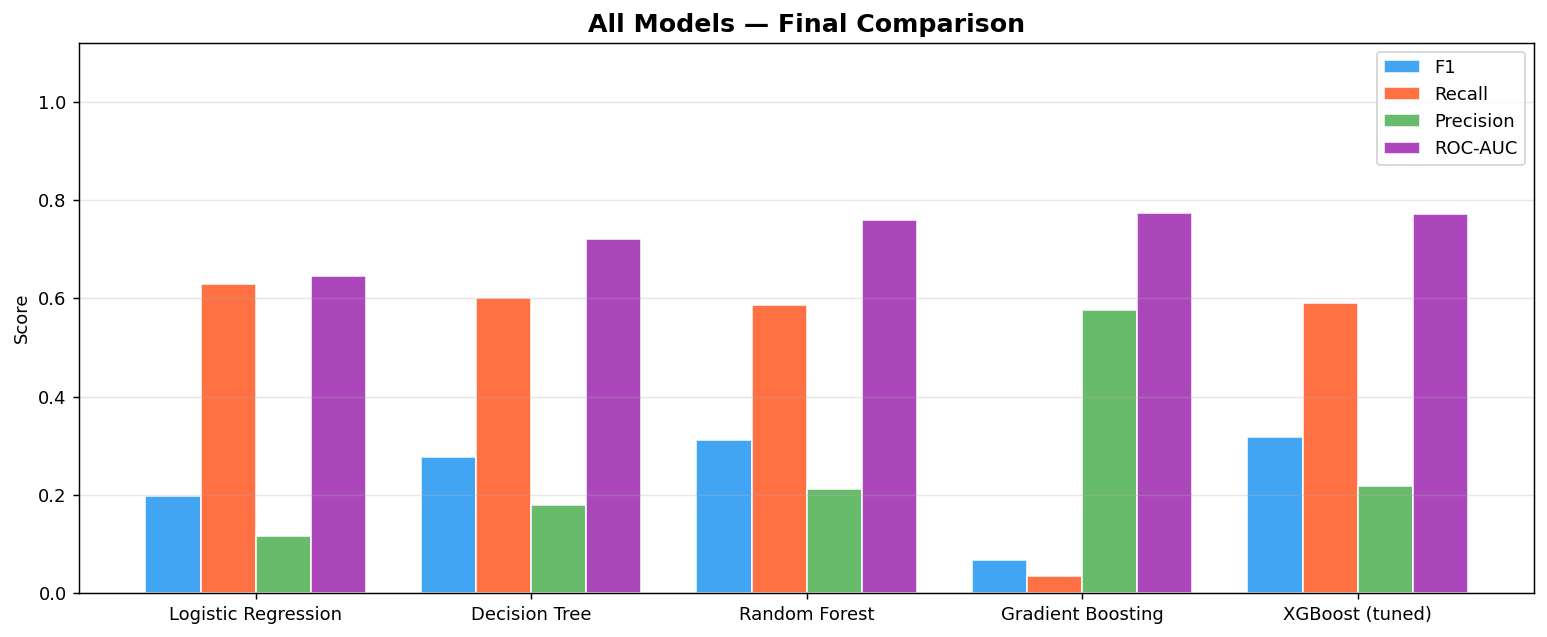

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(summary))
width = 0.2
metric_cols = ['F1','Recall','Precision','ROC-AUC']
colors_bar  = ['#2196F3','#FF5722','#4CAF50','#9C27B0']

for i, (col, color) in enumerate(zip(metric_cols, colors_bar)):
    bars = ax.bar(x + i*width, summary[col], width, label=col, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(summary.index, fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('All Models — Final Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(IMG + '03_final_comparison.png', bbox_inches='tight')
plt.show()

> **Key insight:** XGBoost with tuned hyperparameters achieves the best F1 and ROC-AUC across all five models. The progression is clear: simple baselines → ensembles → boosted + tuned. Beyond the supervised task, customer segmentation showed that Olist's base is dominated by one-time buyers — a structural challenge no ML model can fix, but a segmentation strategy can address.